# Harnessing Transfer Learning: Fine-Tuning VGG16 for Image Classification

## Download the data from Kaggle
This code first sets up your Kaggle API credentials in the Colab environment. Then, it uses the Kaggle API to download the "Dogs vs. Cats" dataset provided by user 'salader'.

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!kaggle datasets download -d salader/dogs-vs-cats

Dataset URL: https://www.kaggle.com/datasets/salader/dogs-vs-cats
License(s): unknown


## Unzip the data
The code utilizes the zipfile library to open the downloaded `'dogs-vs-cats.zip'` file. Subsequently, it extracts all the files and folders within the zip archive to the current working directory ('/content') and closes the file, making the dataset ready for use.

In [4]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogs-vs-cats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

## Import the libraries
The code imports necessary libraries for numerical computation (numpy), deep learning (tensorflow, keras), building neural networks (Sequential, Dense, Flatten), using the VGG16 model (keras.applications.vgg16), image processing (keras.preprocessing), and plotting (matplotlib.pyplot). These libraries provide the tools for loading, processing, and training on image data using deep learning models.

In [5]:
import numpy as np # For numerical operations
import tensorflow as tf # For deep learning
from tensorflow import keras # Keras API for building and training neural networks
from keras import Sequential # For creating a sequential model
from keras.layers import Dense,Flatten # For adding layers to the model
from keras.applications.vgg16 import VGG16 # For using the VGG16 pre-trained model
from keras.preprocessing import image # For image preprocessing
import matplotlib.pyplot as plt # For plotting

## Load the pre-trained VGG16 model

This code loads the VGG16 model pre-trained on ImageNet, removing its classification layers (include_top=False) to use its feature extraction capabilities for a new, custom classification task. It also specifies the input image size as 150x150 pixels with 3 color channels.

### Why Classification Layers are Removed

- Transfer Learning: By removing the original classification layers, we can replace them with new layers tailored to our specific classification problem (e.g., cats vs. dogs instead of ImageNet's 1000 classes). This leverages the pre-trained features for better performance.
- Feature Extraction: We are primarily interested in using VGG16 as a feature extractor. The convolutional layers learn rich features from images, and these features can be reused for different tasks. We discard the old classification layers because they are specific to ImageNet and not relevant to our new task.

In [6]:
conv_base = VGG16(
    weights='imagenet', # Use weights pre-trained on ImageNet
    include_top = False, # Exclude the fully connected layers at the top
    input_shape=(150,150,3) # Specify the input shape for images
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Fine-tuning: Make some layers trainable
This code first sets the `conv_base` model to be trainable, allowing its weights to be updated during training. Then, it iterates through the layers of the model, making only the layers starting from 'block5_conv1' trainable, effectively "freezing" the earlier layers. Finally, it prints the names and trainable status of each layer in the `conv_base` model.

In [7]:
conv_base.trainable = True # Allow training of some layers

set_trainable = False # Flag to control which layers are trainable

for layer in conv_base.layers: # Iterate through layers
  if layer.name == 'block5_conv1': # Start training from this layer
    set_trainable = True
  if set_trainable:
    layer.trainable = True # Make layers trainable
  else:
    layer.trainable = False # Keep layers frozen

# Print layer names and trainable status
for layer in conv_base.layers:
  print(layer.name,layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


## Display model summary
`conv_base.summary()` displays a concise summary of the conv_base model's architecture. This includes information about layers, output shapes, and the number of parameters.

In [8]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

## Create a sequential model
This code initializes a `Sequential` model, which is a linear stack of layers. It then adds the pre-trained `conv_base` (VGG16) for feature extraction, a flattening layer to convert the output to a 1D vector, and dense layers for classification. The final dense layer uses a sigmoid activation function, making it suitable for binary classification tasks.

In [9]:
model = Sequential()

# Add layers to the model
model.add(conv_base) # Add the VGG16 base
model.add(Flatten()) # Flatten the output for the dense layers
model.add(Dense(256,activation='relu')) # Add a dense layer with ReLU activation
model.add(Dense(1,activation='sigmoid')) # Add output layer with sigmoid activation

## Create image datasets from directories
This code creates two image datasets, `train_ds` and `validation_ds`, using `image_dataset_from_directory`. It loads images from the '/content/train' and '/content/test' directories, respectively, inferring labels from the directory structure. The label_mode is set to 'int' for integer labels, and images are resized to 150x150 pixels. Both datasets are batched with a `batch_size` of 32 for efficient processing during training and validation.

In [10]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/train', # Path to training data
    labels='inferred', # Infer labels from directory structure
    label_mode = 'int', # Use integer labels
    batch_size=32, # Set batch size
    image_size=(150,150) # Resize images
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test', # Path to validation data
    labels='inferred', # Infer labels from directory structure
    label_mode = 'int', # Use integer labels
    batch_size=32, # Set batch size
    image_size=(150,150) # Resize images
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


## Normalize image data
This code defines a function `process` to normalize image pixel values to the range [0, 1] and then applies it to both the training (`train_ds`) and validation (`validation_ds`) datasets. This normalization is a common preprocessing step in deep learning to improve model performance.

In [11]:
def process(image,label):
    image = tf.cast(image/255. ,tf.float32) # Normalize pixel values
    return image,label

train_ds = train_ds.map(process) # Apply normalization to training data
validation_ds = validation_ds.map(process) # Apply normalization to validation data

## Compile the model
This code compiles the `model` using the RMSprop optimizer with a learning rate of 1e-5. It specifies 'binary_crossentropy' as the loss function, suitable for binary classification problems. Finally, it sets 'accuracy' as the metric to track during training.

In [12]:
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-5), # Use RMSprop optimizer
    loss='binary_crossentropy', # Use binary cross-entropy loss
    metrics=['accuracy'] # Track accuracy metric
  )

## Train the model

This line starts the training process for the `model` using the `fit` method. It trains for 10 epochs (iterations over the entire training dataset) and uses `validation_ds` for evaluating the model's performance during training. The training history (metrics like loss and accuracy over epochs) is stored in the `history` variable.

In [13]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 141ms/step - accuracy: 0.8489 - loss: 0.3340 - val_accuracy: 0.9354 - val_loss: 0.1548
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.9426 - loss: 0.1439 - val_accuracy: 0.9410 - val_loss: 0.1386
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.9630 - loss: 0.1021 - val_accuracy: 0.9400 - val_loss: 0.1414
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.9741 - loss: 0.0749 - val_accuracy: 0.9530 - val_loss: 0.1217
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 146ms/step - accuracy: 0.9839 - loss: 0.0508 - val_accuracy: 0.9468 - val_loss: 0.1481
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 137ms/step - accuracy: 0.9903 - loss: 0.0355 - val_accuracy: 0.9530 - val_loss: 0.1312
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.9951 - loss: 0.0225 - val_accuracy: 0.9428 - val_loss: 0.1786
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 137ms/step - accuracy: 0.9963 - loss:

## Plot training accuracy and validation accuracy
This code plots the training accuracy and validation accuracy over epochs. Training accuracy is plotted in red, and validation accuracy is plotted in blue. A legend is displayed to differentiate the two lines, and the plot is then shown.

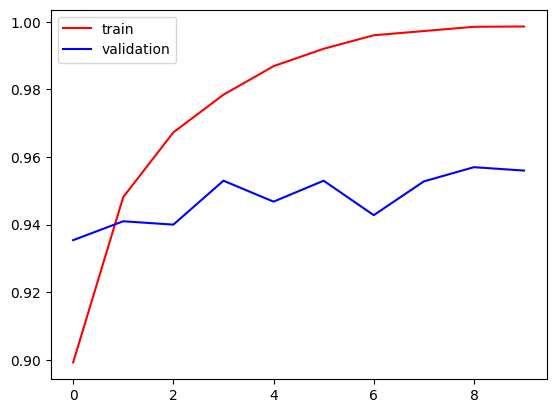

In [14]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

## Plot training loss and validation loss
This code plots the training loss and validation loss over epochs. Training loss is plotted in red, and validation loss is plotted in blue. A legend is displayed to differentiate the two lines, and the plot is then shown.

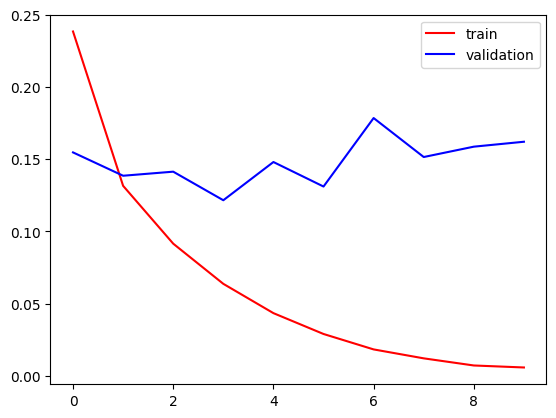

In [15]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

## Function to predict image class
This function `predict_image_class` takes an image path and the trained model as input. It loads and preprocesses the image (resizing, converting to array, normalizing). Then, it uses the model to predict the class of the image ("Dog" or "Cat" based on the prediction probability). Finally, it displays the image along with the predicted class.

In [16]:
def predict_image_class(image_path, model):
  img = image.load_img(image_path, target_size=(150, 150))  # Load and resize image
  img_array = image.img_to_array(img)  # Convert to NumPy array
  img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
  img_array = img_array / 255.0  # Normalize pixel values

  prediction = model.predict(img_array)  # Make prediction
  predicted_class = "Dog" if prediction[0][0] > 0.5 else "Cat"  # Determine class

  # Display the image and prediction
  plt.imshow(img)
  plt.title(f"Predicted Class: {predicted_class}")
  plt.axis('off')
  plt.show()

This line calls the `predict_image_class` function to predict the class of the image located at "/content/test/cats/cat.10000.jpg" using the trained `model`. To see the output, run the code.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


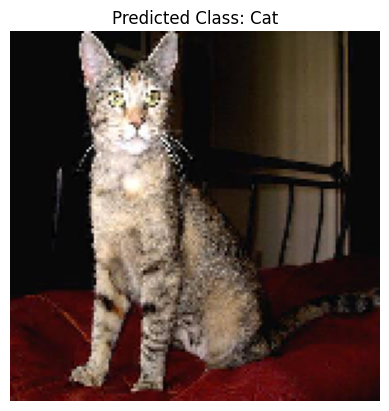

In [17]:
predict_image_class("/content/test/cats/cat.10000.jpg", model)  # Assuming 'model' is your trained model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


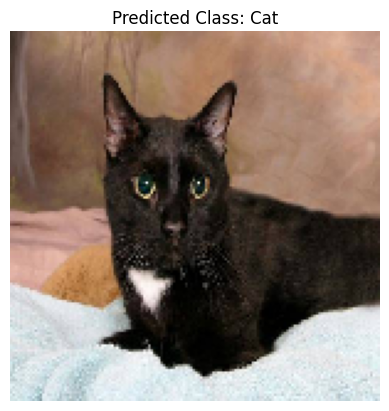

In [18]:
predict_image_class('/content/test/cats/cat.10128.jpg', model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


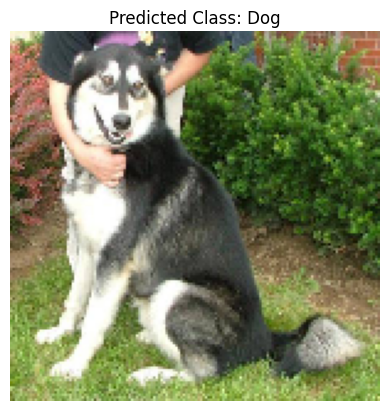

In [19]:
predict_image_class('/content/test/dogs/dog.10021.jpg', model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


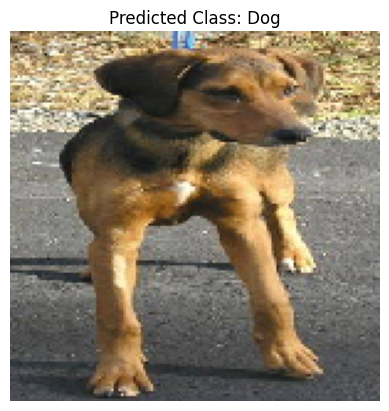

In [20]:
predict_image_class('/content/test/dogs/dog.10249.jpg', model)